# Basketball Free Throw Mechanics

### Goals
- Using the SPL Open Data set of 125 free throws, plot the movement of a specific keypoint (e.g. right elbow) and measure its variability across the whole data set.


In [2]:
%config InlineBackend.figure_format = 'retina'

In [3]:
import json
import os

In [4]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/gdrive')

# Update the path to point to your Google Drive location
data_path = "/content/gdrive/My Drive/Python Coding/Labs/SPL-Open-Data/basketball/freethrow/data/P0001/BB_FT_P0001_T{}.json"

Mounted at /content/gdrive


In [5]:
trial_id = "0001"
with open(data_path.format(trial_id)) as json_file:
    free_throw_data = json.load(json_file)

code for 0001 was not working as the upload would not allow me. I have used trial_id 0006 as this was the first one available

In [6]:
connections = [
    ("R_EYE", "L_EYE"),
    ("R_EYE", "NOSE"),
    ("L_EYE", "NOSE"),
    ("R_EYE", "R_EAR"),
    ("L_EYE", "L_EAR"),
    ("R_SHOULDER", "L_SHOULDER"),
    ("R_SHOULDER", "R_ELBOW"),
    ("L_SHOULDER", "L_ELBOW"),
    ("R_ELBOW", "R_WRIST"),
    ("L_ELBOW", "L_WRIST"),
    ("R_SHOULDER", "R_HIP"),
    ("L_SHOULDER", "L_HIP"),
    ("R_HIP", "L_HIP"),
    ("R_HIP", "R_KNEE"),
    ("L_HIP", "L_KNEE"),
    ("R_KNEE", "R_ANKLE"),
    ("L_KNEE", "L_ANKLE"),
    ("R_WRIST", "R_1STFINGER"),
    ("R_WRIST", "R_5THFINGER"),
    ("L_WRIST", "L_1STFINGER"),
    ("L_WRIST", "L_5THFINGER"),
    ("R_ANKLE", "R_1STTOE"),
    ("R_ANKLE", "R_5THTOE"),
    ("L_ANKLE", "L_1STTOE"),
    ("L_ANKLE", "L_5THTOE"),
    ("R_ANKLE", "R_CALC"),
    ("L_ANKLE", "L_CALC"),
    ("R_1STTOE", "R_5THTOE"),
    ("L_1STTOE", "L_5THTOE"),
    ("R_1STTOE", "R_CALC"),
    ("L_1STTOE", "L_CALC"),
    ("R_5THTOE", "R_CALC"),
    ("L_5THTOE", "L_CALC"),
    ("R_1STFINGER", "R_5THFINGER"),
    ("L_1STFINGER", "L_5THFINGER"),
    ("R_1STFINGER", "R_5THFINGER"),
    ("L_1STFINGER", "L_5THFINGER"),
]

In [7]:
zlim=8.0
elev=15.0
azim=40.0
ball_color="#ee6730"
ball_size=8.0
xbuffer=4.0
ybuffer=4.0

In [8]:
import matplotlib.pyplot as plt

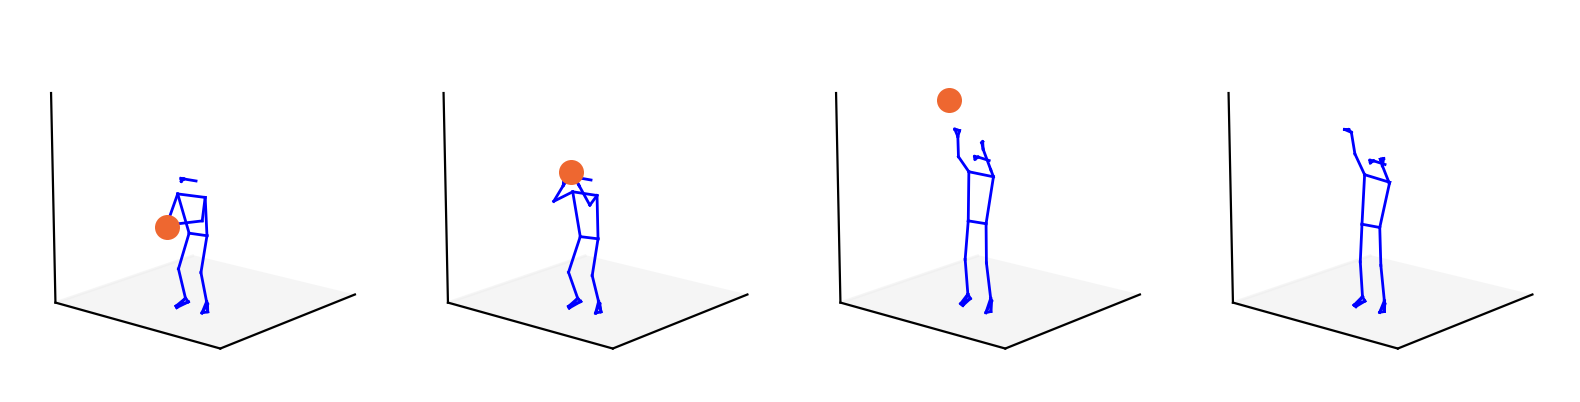

In [9]:
def plot_frames_subplot(data, frame_nos):
    fig = plt.figure(figsize=(8, 24))
    for i, frame_no in enumerate(frame_nos):
        ax = fig.add_subplot(1, 4, i+1, projection="3d")
        landmarks = data['tracking'][frame_no]['data']['player']
        ball = data['tracking'][frame_no]['data']['ball']

        ax.set_zlim([0, zlim])
        ax.set_box_aspect([1, 1, 1])
        ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_zticks([])
        ax.view_init(elev=elev, azim=azim)

        for connection in connections:
            point1 = landmarks[connection[0]]
            point2 = landmarks[connection[1]]
            xs = [point1[0], point2[0]]
            ys = [point1[1], point2[1]]
            zs = [point1[2], point2[2]]
            ax.plot(xs, ys, zs, color='blue', linewidth=1)

        ax.plot(*ball, "o", markersize=ball_size, c=ball_color)
        ax.set_xlim([22, 30])
        ax.set_ylim([-5, 3])

    plt.tight_layout()
    plt.show()

plot_frames_subplot(free_throw_data, [155, 165, 175, 185])


In [10]:
trials = []
for i in range(1, 126): # Trials are numbered 0001 to 0125
    trial_id = f"{i:04d}"
    try:
        with open(data_path.format(trial_id)) as json_file:
            free_throw_data = json.load(json_file)
            locations = []
            for frame in free_throw_data['tracking']:
                data = frame['data']['player']
                rhip = data['R_HIP']
                locations.append(rhip)
            trials.append(locations)
    except FileNotFoundError:
        continue

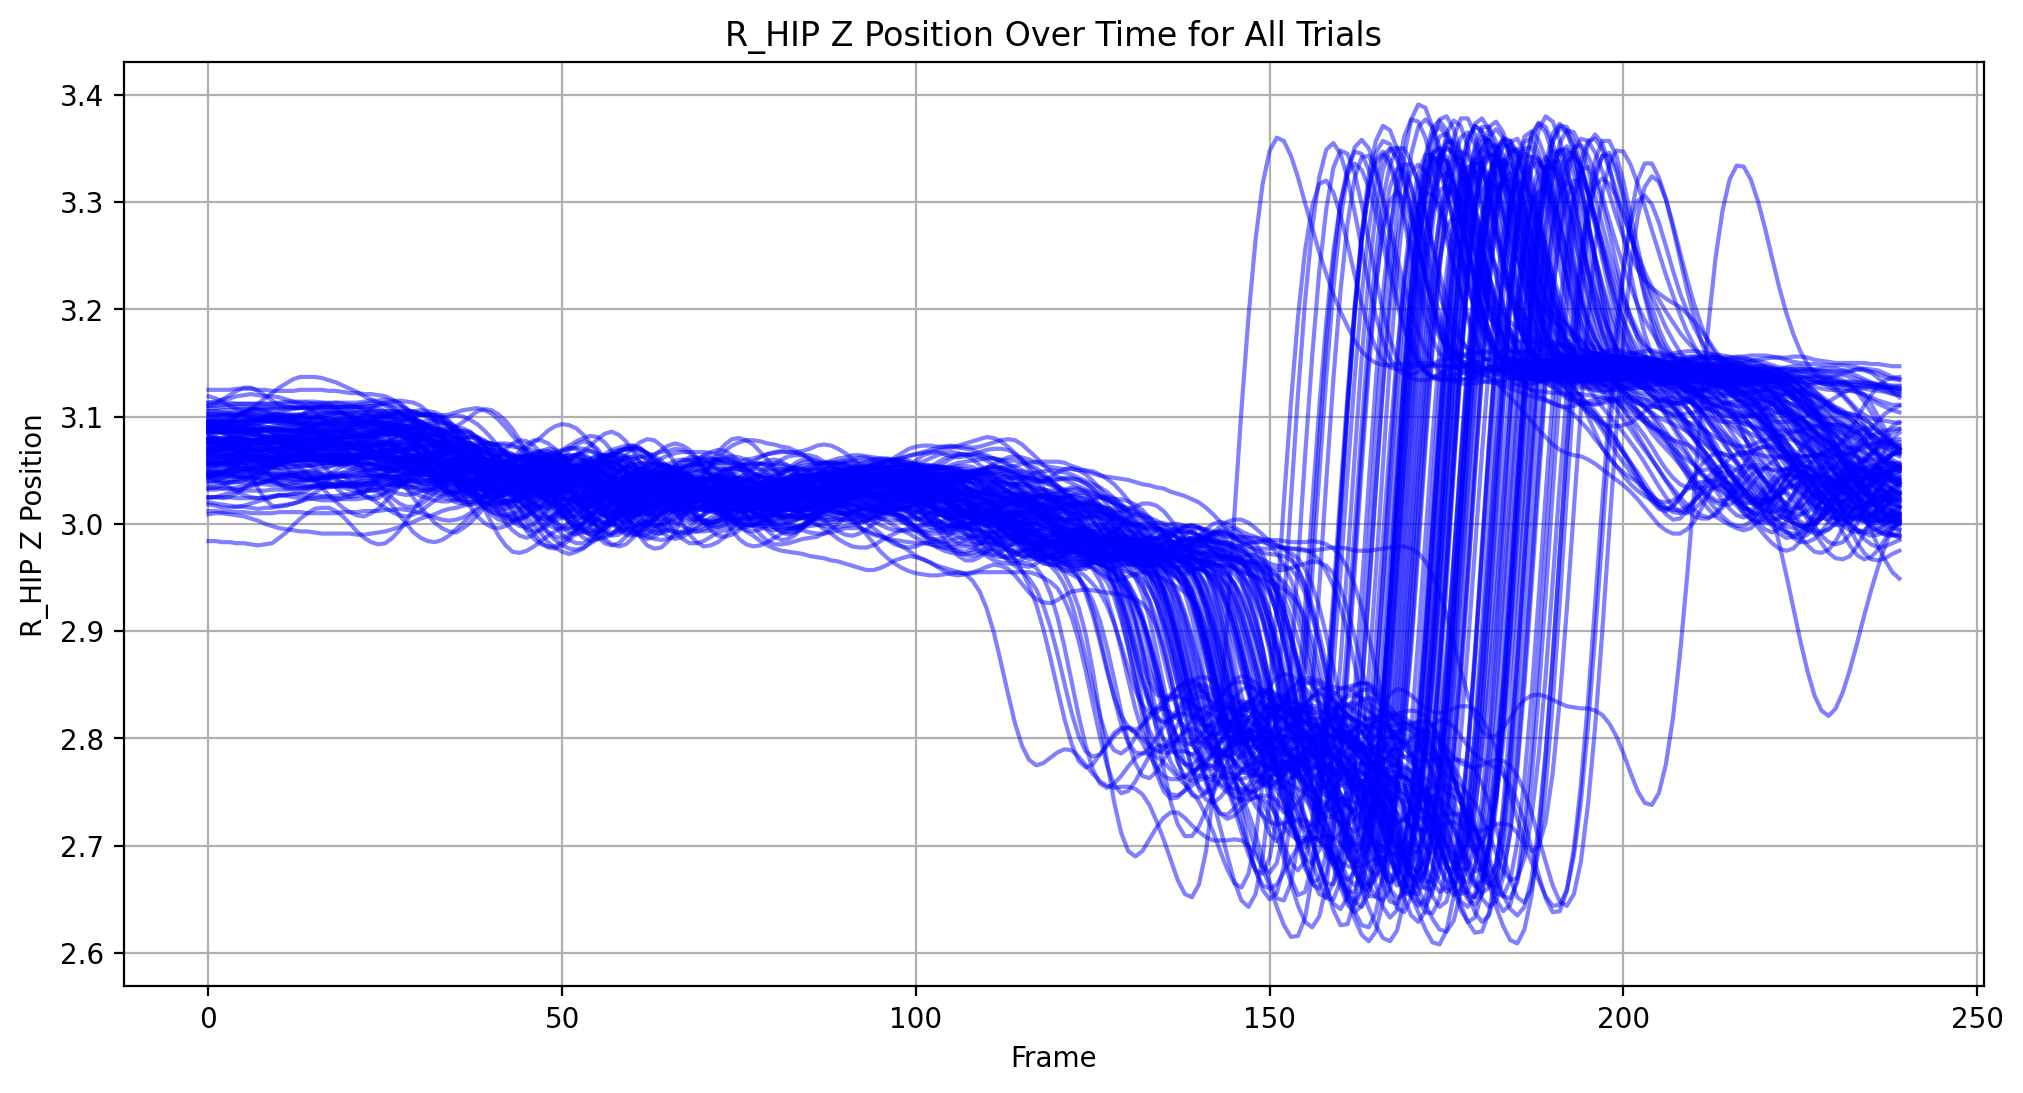

In [11]:
plt.figure(figsize=(12, 6))
for trial in trials:
    plt.plot([loc[2] for loc in trial], alpha=0.5, color='blue')
plt.ylabel('R_HIP Z Position')
plt.xlabel('Frame')
plt.title('R_HIP Z Position Over Time for All Trials')
plt.grid(True)
plt.show()

In [12]:
import numpy as np

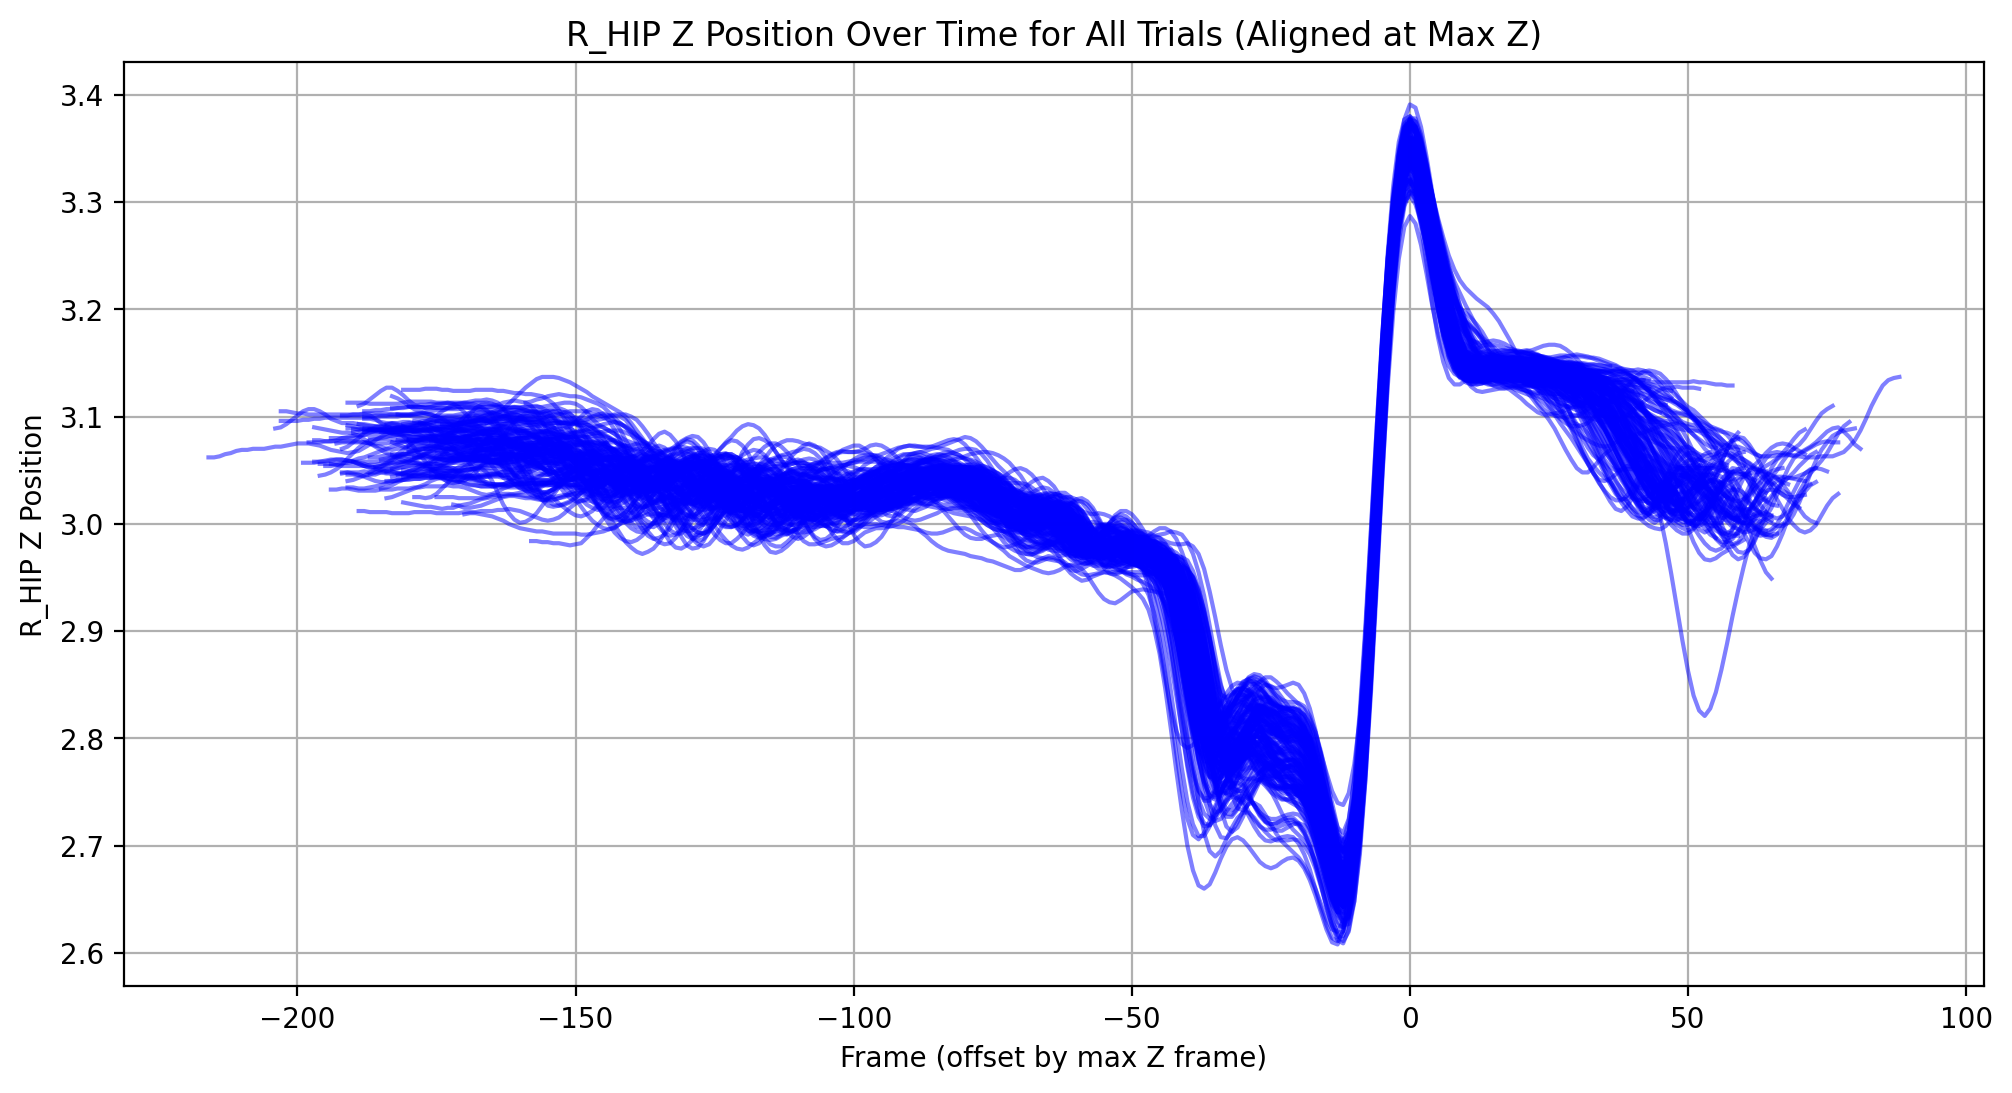

In [13]:
max_z_frames = []
for trial in trials:
    z_values = [loc[2] for loc in trial]
    max_z_frame = np.argmax(z_values)
    max_z_frames.append(max_z_frame)

plt.figure(figsize=(12, 6))
for trial, offset in zip(trials, max_z_frames):
    z_track = [loc[2] for loc in trial]
    x = np.arange(len(z_track)) - offset
    plt.plot(x, z_track, alpha=0.5, color='blue')
plt.ylabel('R_HIP Z Position')
plt.xlabel('Frame (offset by max Z frame)')
plt.title('R_HIP Z Position Over Time for All Trials (Aligned at Max Z)')
plt.grid(True)
plt.show()

/tmp/ipython-input-3690357634.py:15: RuntimeWarning: Mean of empty slice
  mean_z = np.nanmean(aligned_z, axis=0)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


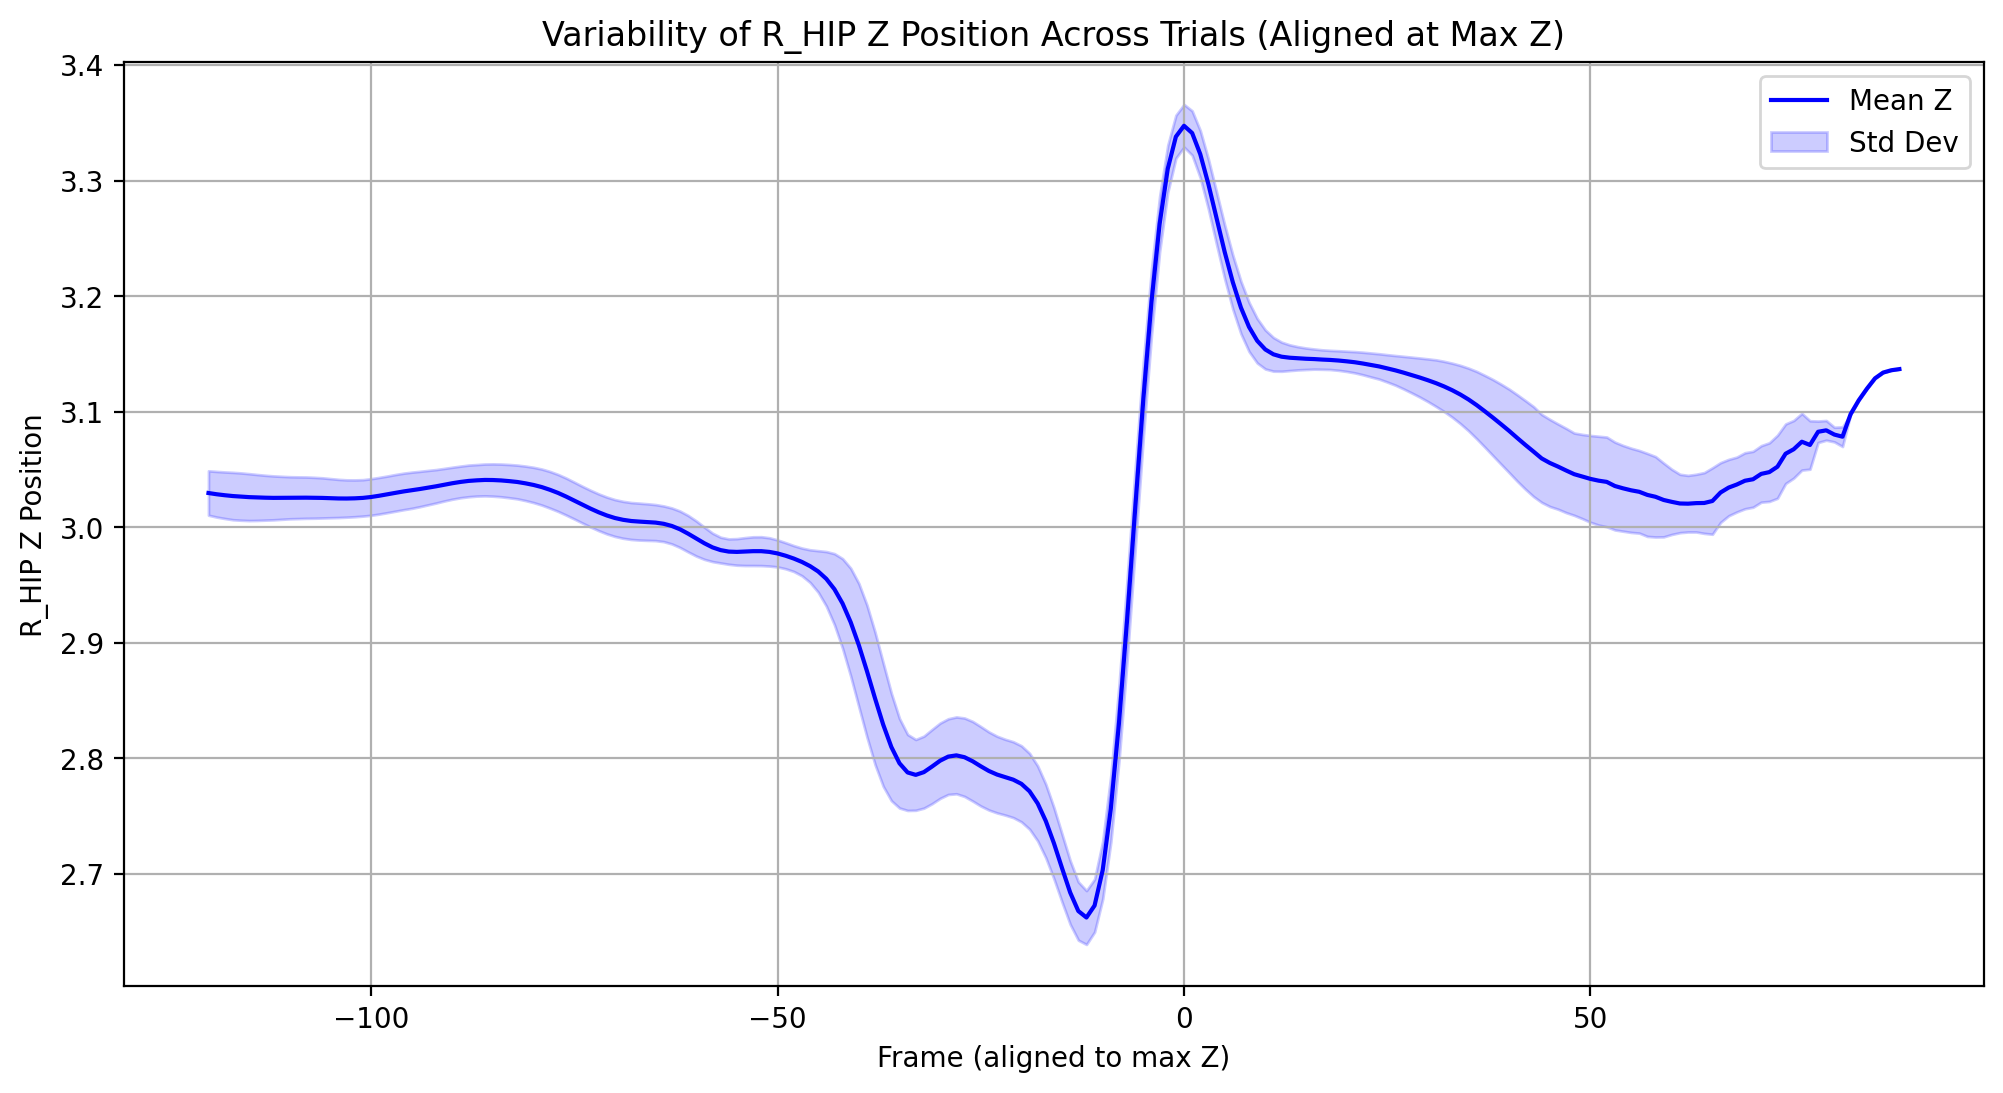

In [14]:
# Compute mean and standard deviation per frame (aligned to max Z)
max_length = max(len(trial) for trial in trials)
aligned_z = np.full((len(trials), max_length), np.nan)

for i, trial in enumerate(trials):
    z = [loc[2] for loc in trial]
    offset = np.argmax(z)
    start = max_length // 2 - offset
    end = start + len(z)
    if start < 0:
        z = z[-start:]
        start = 0
    aligned_z[i, start:end] = z

mean_z = np.nanmean(aligned_z, axis=0)
std_z = np.nanstd(aligned_z, axis=0)
frames = np.arange(-max_length//2, max_length//2)

plt.figure(figsize=(12, 6))
plt.plot(frames, mean_z, color='blue', label='Mean Z')
plt.fill_between(frames, mean_z - std_z, mean_z + std_z, color='blue', alpha=0.2, label='Std Dev')
plt.xlabel('Frame (aligned to max Z)')
plt.ylabel('R_HIP Z Position')
plt.title('Variability of R_HIP Z Position Across Trials (Aligned at Max Z)')
plt.legend()
plt.grid(True)
plt.show()

#Lab 8 Start (Using Right Wrist in Y position)
- based on above information, the individual is a right handed shooter and therefore wanted to analyze the change in location during a shot.

In [15]:
trials = []
for i in range(1, 126):  # Trials are numbered 0001 to 0125
    trial_id = f"{i:04d}"
    try:
        with open(data_path.format(trial_id)) as json_file:
            free_throw_data = json.load(json_file)
            locations = []
            for frame in free_throw_data['tracking']:
                data = frame['data']['player']
                rwrist = data['R_WRIST']  # Changed from R_HIP
                locations.append(rwrist)
            trials.append(locations)
    except FileNotFoundError:
        continue

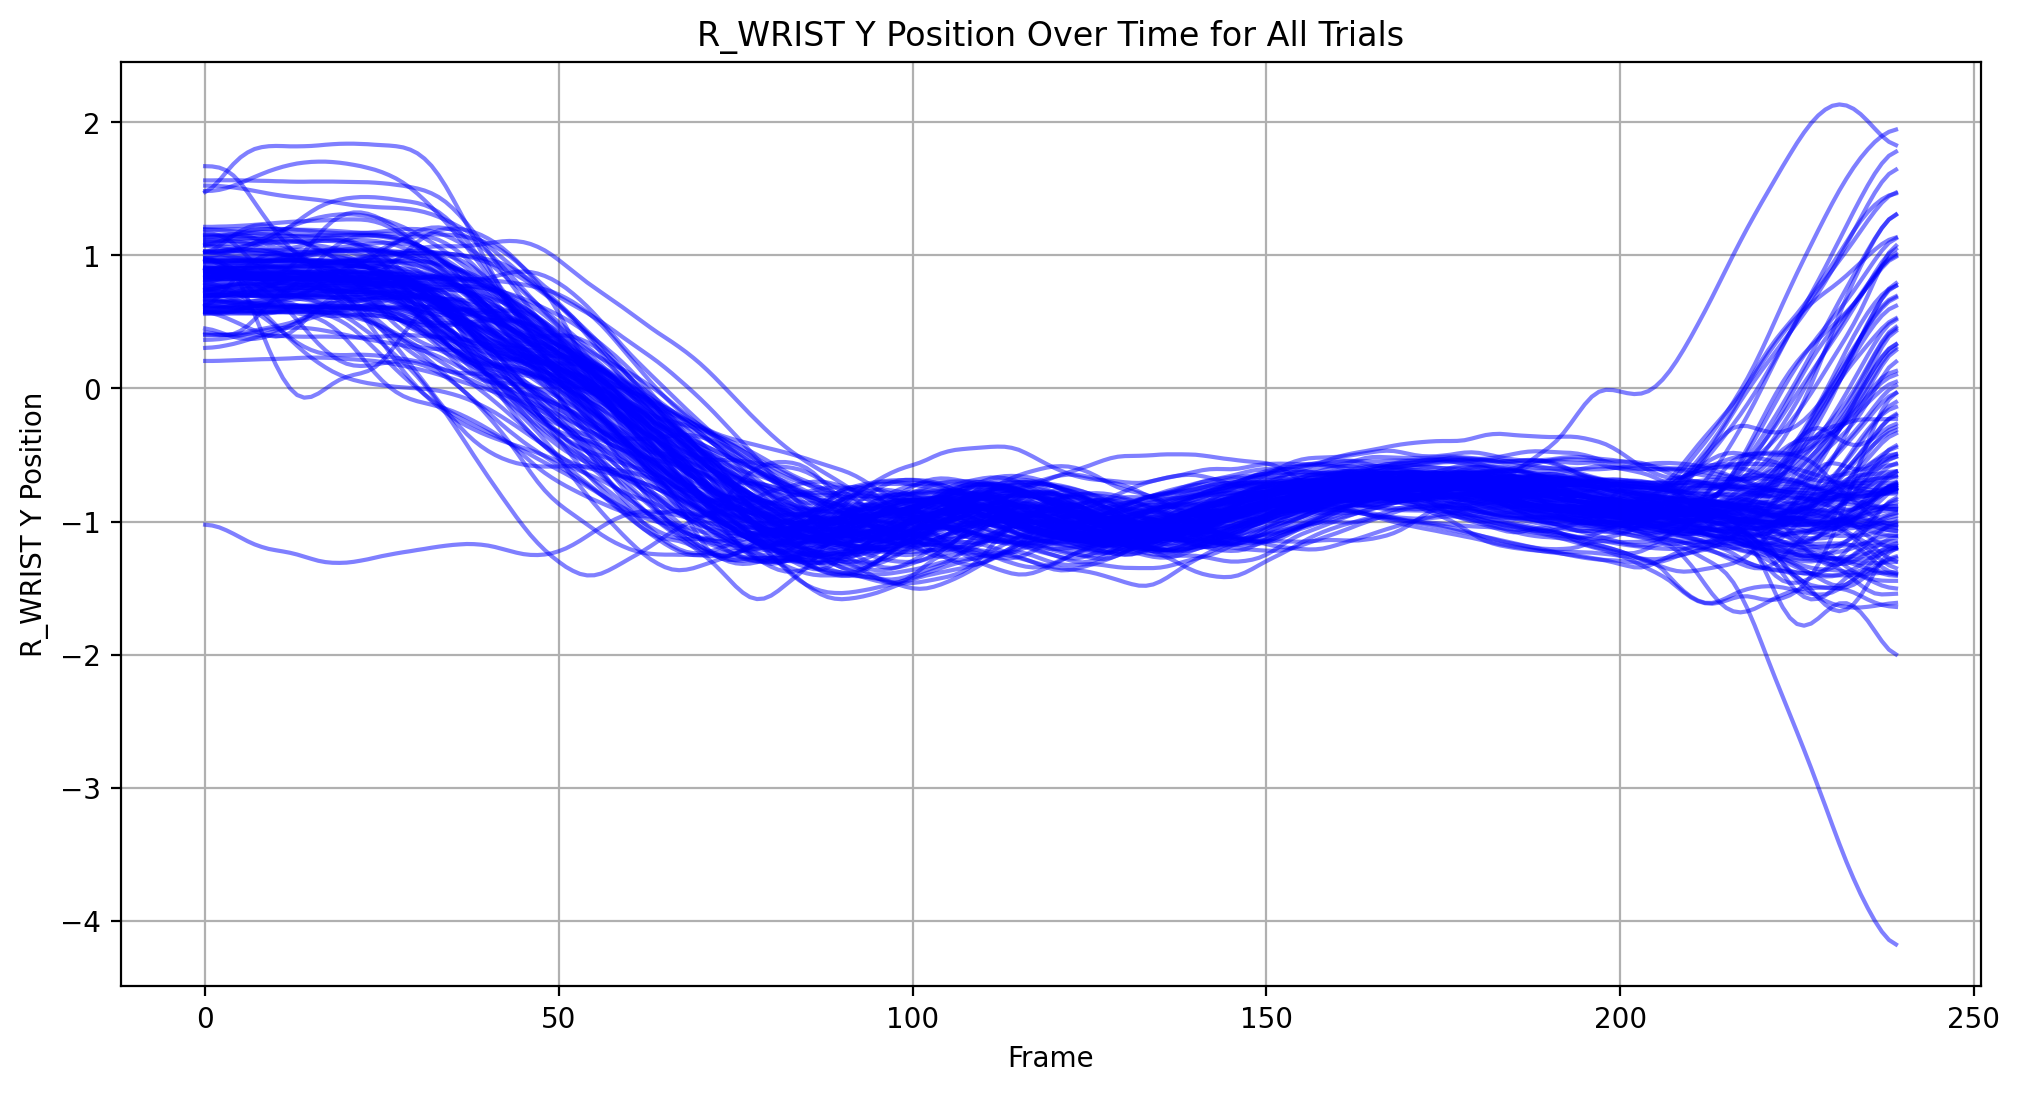

In [16]:
# Plot R_WRIST Y position over time for all trials
plt.figure(figsize=(12, 6))
for trial in trials:
    plt.plot([loc[1] for loc in trial], alpha=0.5, color='blue')  # Changed [2] to [1] for Y
plt.ylabel('R_WRIST Y Position')  # Updated label
plt.xlabel('Frame')
plt.title('R_WRIST Y Position Over Time for All Trials')  # Updated title
plt.grid(True)
plt.show()



In [17]:
# Find the frame with maximum Y position for each trial
max_y_frames = []  # Changed from max_z_frames
for trial in trials:
    y_values = [loc[1] for loc in trial]  # Changed [2] to [1] for Y
    max_y_frame = np.argmax(y_values)  # Changed variable name
    max_y_frames.append(max_y_frame)

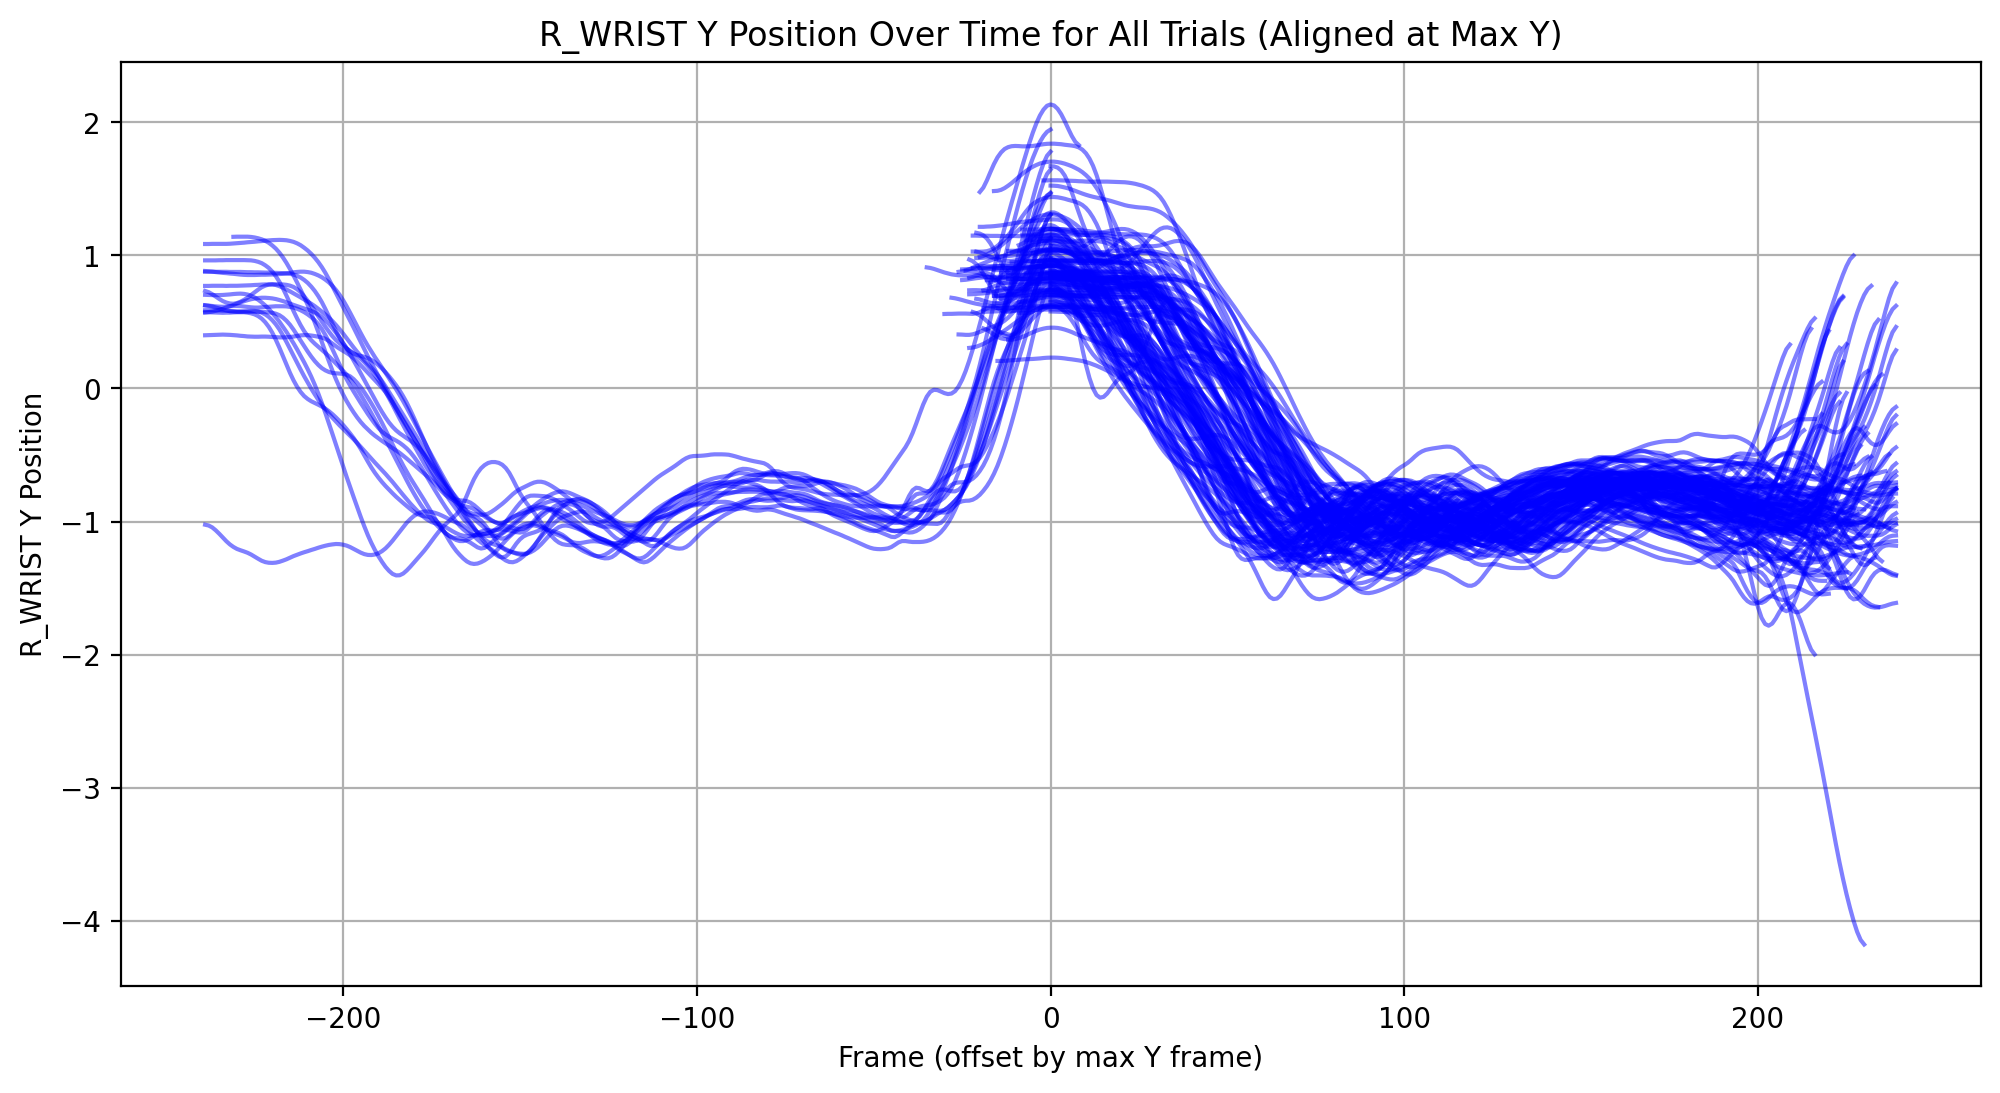

In [18]:
# Plot aligned to max Y frame
plt.figure(figsize=(12, 6))
for trial, offset in zip(trials, max_y_frames):
    y_track = [loc[1] for loc in trial]  # Changed to Y position
    x = np.arange(len(y_track)) - offset
    plt.plot(x, y_track, alpha=0.5, color='blue')
plt.ylabel('R_WRIST Y Position')  # Updated label
plt.xlabel('Frame (offset by max Y frame)')  # Updated label
plt.title('R_WRIST Y Position Over Time for All Trials (Aligned at Max Y)')  # Updated title
plt.grid(True)
plt.show()

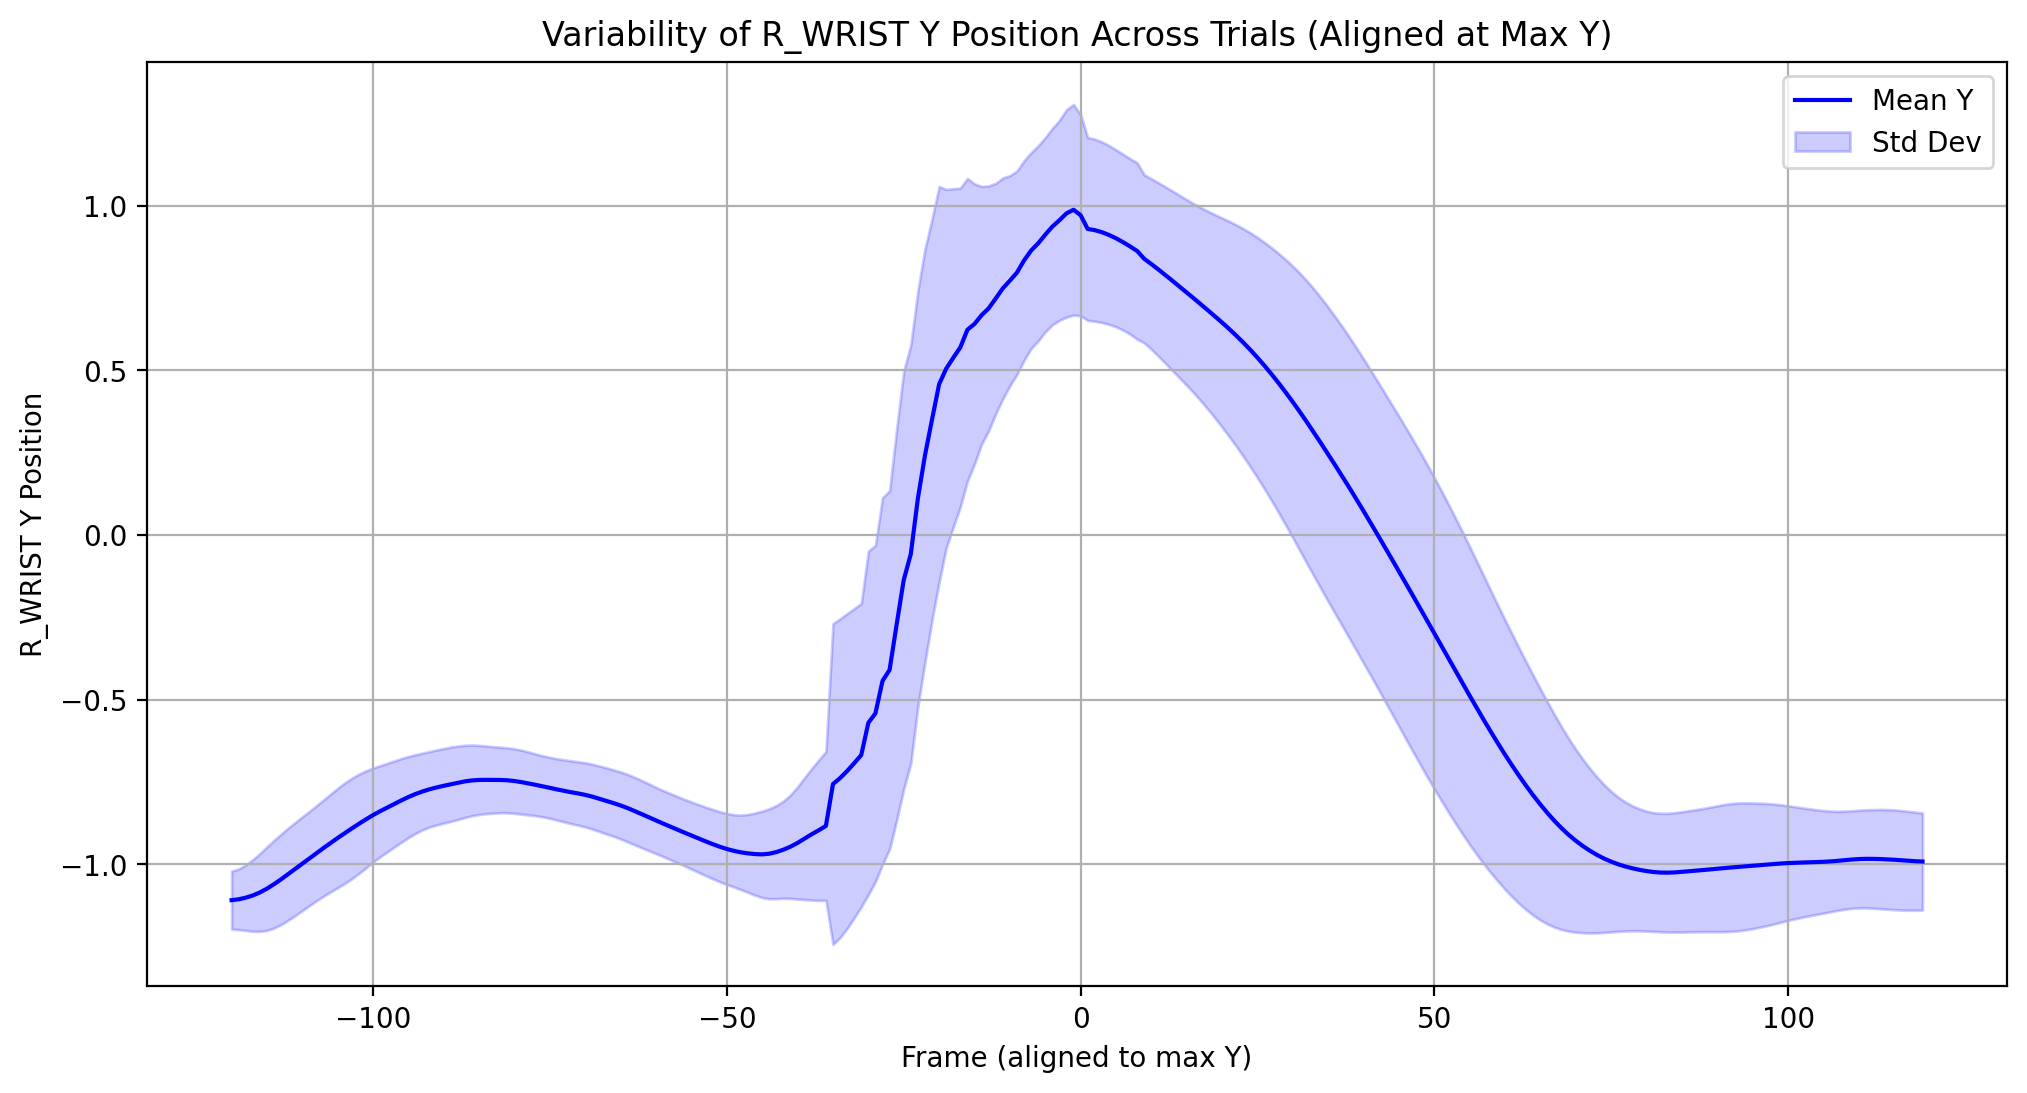

In [19]:
# Compute mean and standard deviation per frame (aligned to max Y)
max_length = max(len(trial) for trial in trials)
aligned_y = np.full((len(trials), max_length), np.nan)

for i, trial in enumerate(trials):
    y = [loc[1] for loc in trial]
    offset = np.argmax(y)
    start = max_length // 2 - offset
    end = start + len(y)

    # Handle trials that are too long or start before 0
    if start < 0:
        y = y[-start:]  # Trim from the beginning
        start = 0
        end = start + len(y)

    if end > max_length:
        y = y[:max_length - start]  # Trim from the end
        end = max_length

    aligned_y[i, start:end] = y

mean_y = np.nanmean(aligned_y, axis=0)
std_y = np.nanstd(aligned_y, axis=0)
frames = np.arange(-max_length//2, max_length//2)

# Plot mean and standard deviation
plt.figure(figsize=(12, 6))
plt. plot(frames, mean_y, color='blue', label='Mean Y')
plt.fill_between(frames, mean_y - std_y, mean_y + std_y, color='blue', alpha=0.2, label='Std Dev')
plt.xlabel('Frame (aligned to max Y)')
plt.ylabel('R_WRIST Y Position')
plt.title('Variability of R_WRIST Y Position Across Trials (Aligned at Max Y)')
plt.legend()
plt.grid(True)
plt.show()

# Extra: Animated graph

- had to use a reduced version due to processing speed on my laptop

In [29]:
# FIXED AXIS VERSION — now looks perfect vertically and horizontally
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# THESE TWO LINES FIX EVERYTHING:
ax.set_xlim(22, 30)   # ← court front-to-back
ax.set_ylim(-5, 3)    # ← left-right around free-throw line
ax.set_zlim(0, 2.7)

ax.view_init(elev=25, azim=-70)
ax.set_title(f"Right Wrist Variability ({len(all_right_wrist_trajs)} trials)", fontsize=16)
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.set_zlabel('Z (m)')

# Basketball — now in the correct location
ax.scatter(0, 0, 1.45, s=800, c='#ee6730', edgecolors='black', depthshade=True)
ax.text(0, 0, 1.7, "BALL", color='white', fontsize=12, ha='center', weight='bold')

# Rest of your lines (same as before)
lines = [ax.plot([], [], [], 'lightgray', lw=1.2, alpha=0.7)[0] for _ in all_right_wrist_trajs]
mean_line, = ax.plot([], [], [], 'gold', lw=5, label='Mean Path')
upper, = ax.plot([], [], [], 'cyan', lw=3, alpha=0.7)
lower, = ax.plot([], [], [], 'cyan', lw=3, alpha=0.7)
ax.legend()

def animate(f):
    for i, line in enumerate(lines):
        line.set_data(traj_array[i,:f,0], traj_array[i,:f,1])
        line.set_3d_properties(traj_array[i,:f,2])
    mean_line.set_data(mean_traj[:f,0], mean_traj[:f,1])
    mean_line.set_3d_properties(mean_traj[:f,2])
    u = mean_traj[:f] + std_traj[:f]
    l = mean_traj[:f] - std_traj[:f]
    upper.set_data(u[:,0], u[:,1]); upper.set_3d_properties(u[:,2])
    lower.set_data(l[:,0], l[:,1]); lower.set_3d_properties(l[:,2])
    return lines + [mean_line, upper, lower]

anim = FuncAnimation(fig, animate, frames=max_frames, interval=50, blit=False)
plt.close(fig)
HTML(anim.to_html5_video())